📊 Generating Raw EEG Visualization...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\sagita pra kosa\AppData\Local\Temp\ipykernel_9312\3397856523.py:24: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(sample_file, preload=True, verbose=False)
C:\Users\sagita pra kosa\AppData\Local\Temp\ipykernel_9312\3397856523.py:24: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(sample_file, preload=True, verbose=False)


✅ Success! Graphic saved to: models/Raw_EEG_Noise_Sample.png


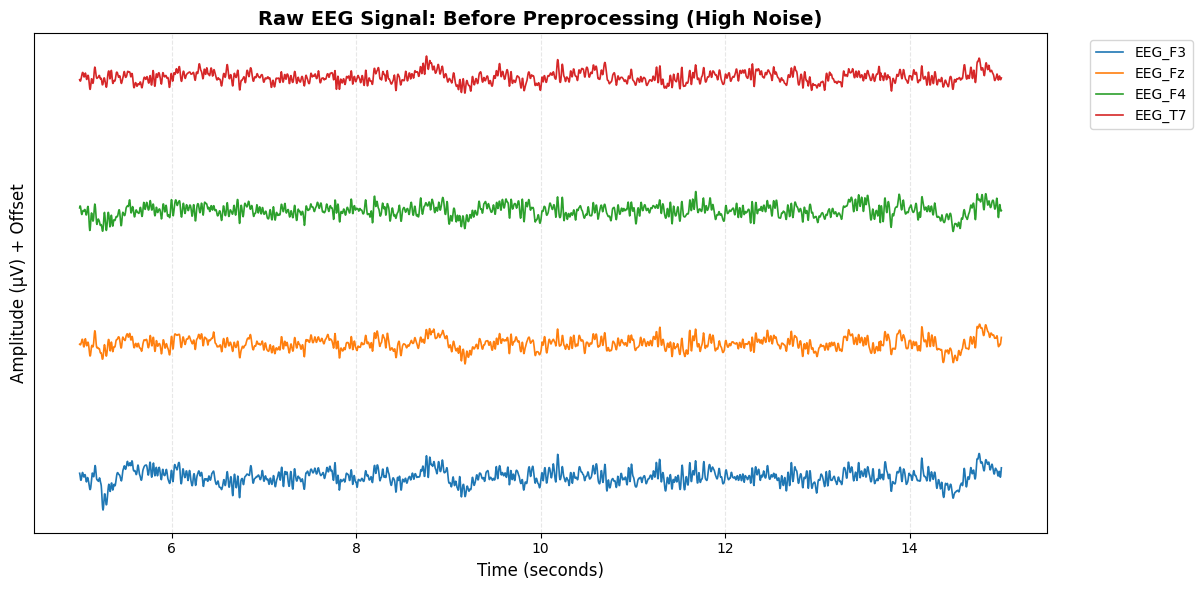

In [1]:
# ==========================================
# VISUALIZE RAW EEG NOISE & ARTIFACTS
# ==========================================

import mne
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os

print("📊 Generating Raw EEG Visualization...")

# 1. Define the path to your raw dataset
# Adjust this path depending on where your .ipynb file is located
raw_dir = Path('../data/raw/bigp3bci')
all_files = list(raw_dir.rglob('*.edf'))

if not all_files:
    raise FileNotFoundError("No .edf files found! Please check your folder path.")

sample_file = all_files[0] 

# 2. Load the raw data (preload=True is needed to extract data array)
raw = mne.io.read_raw_edf(sample_file, preload=True, verbose=False)

# 3. Select a specific 10-second time window (e.g., from second 5 to 15)
start_time = 5
end_time = 15
start_idx, end_idx = raw.time_as_index([start_time, end_time])

# 4. Pick the first 4 channels to clearly show the noise without cluttering the screen
channels_to_plot = raw.ch_names[:4]
raw_subset = raw.copy().pick_channels(channels_to_plot)

# Extract data (MNE stores data in Volts, we multiply by 1e6 to get microvolts)
data, times = raw_subset[:, start_idx:end_idx]
data_uv = data * 1e6  

# 5. Plotting the signals
plt.figure(figsize=(12, 6))

# We add an offset to each channel so they stack vertically instead of overlapping
offset_step = 150  
for i, ch_name in enumerate(channels_to_plot):
    offset = i * offset_step
    plt.plot(times, data_uv[i] + offset, label=ch_name, linewidth=1.2)

plt.title('Raw EEG Signal: Before Preprocessing (High Noise)', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Amplitude (μV) + Offset', fontsize=12)

# Hide Y-axis numbers because the offset makes them irrelevant for pure shape visualization
plt.yticks([]) 

plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# 6. Save the graphic for your technical report
os.makedirs("models", exist_ok=True)
save_path = "models/Raw_EEG_Noise_Sample.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"✅ Success! Graphic saved to: {save_path}")
plt.show()

🧠 Generating Spatial Channel Reduction Map...
✅ Success! Channel reduction map saved to: models/Channel_Reduction_Map.png


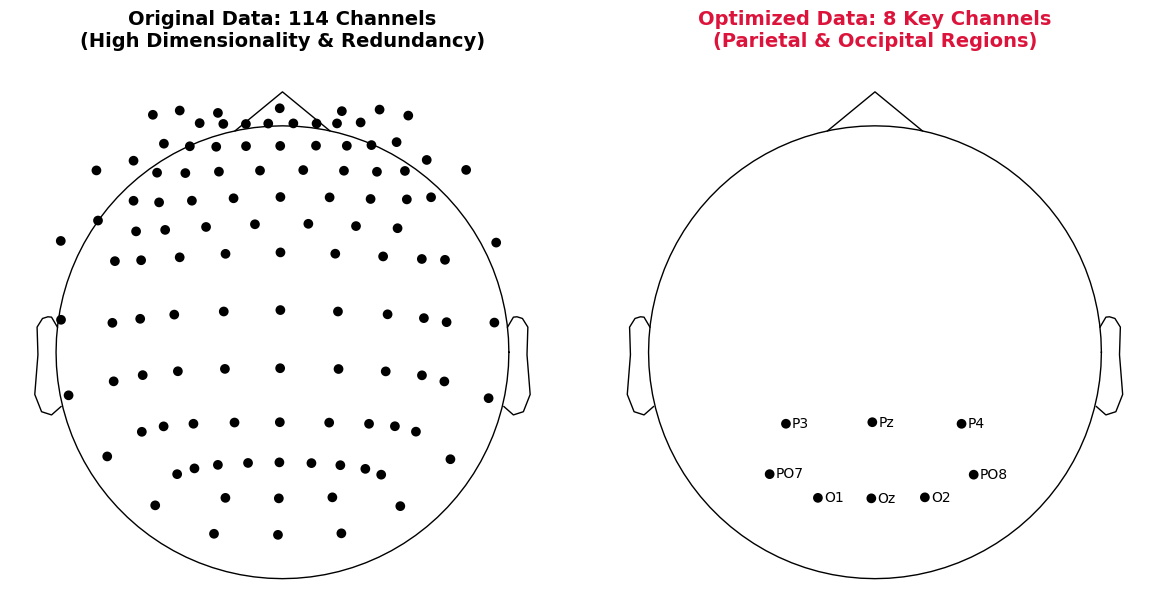

In [3]:
# ==========================================
# VISUALIZE SPATIAL CHANNEL REDUCTION (114 -> 8)
# ==========================================

import mne
import matplotlib.pyplot as plt
import os

print("🧠 Generating Spatial Channel Reduction Map...")

# 1. We use a standard 10-05 EEG system template to simulate the head map
montage = mne.channels.make_standard_montage('standard_1005')

# 2. Define the 8 key channels for P300 (Parietal and Occipital regions)
target_chs = ['Pz', 'P3', 'P4', 'PO7', 'PO8', 'Oz', 'O1', 'O2']

# 3. Simulate the original 114 channels by adding 106 other channels from the template
other_chs = [ch for ch in montage.ch_names if ch not in target_chs][:106]
all_114_chs = target_chs + other_chs

# 4. Create dummy MNE Info objects to draw the maps
info_114 = mne.create_info(ch_names=all_114_chs, sfreq=250, ch_types='eeg')
info_114.set_montage(montage)

info_8 = mne.create_info(ch_names=target_chs, sfreq=250, ch_types='eeg')
info_8.set_montage(montage)

# ==========================================
# 5. DRAWING THE BEFORE-AFTER GRAPHICS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- LEFT PLOT: The Chaotic 114 Channels ---
# Removed the unsupported kwargs (point_colors, etc.)
mne.viz.plot_sensors(info_114, show_names=False, axes=axes[0], show=False)
axes[0].set_title('Original Data: 114 Channels\n(High Dimensionality & Redundancy)', 
                  fontsize=14, fontweight='bold', pad=15)

# --- RIGHT PLOT: The Optimized 8 Channels ---
# Removed the unsupported kwargs
mne.viz.plot_sensors(info_8, show_names=True, axes=axes[1], show=False)
axes[1].set_title('Optimized Data: 8 Key Channels\n(Parietal & Occipital Regions)', 
                  fontsize=14, fontweight='bold', color='crimson', pad=15)

plt.tight_layout()

# 6. Save the graphic for the video/report
os.makedirs('models', exist_ok=True)
save_path = 'models/Channel_Reduction_Map.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"✅ Success! Channel reduction map saved to: {save_path}")
plt.show()

📊 Generating Filtering and Epoching Visuals...
Using default location ~/mne_data for sample...
Creating C:\Users\sagita pra kosa\mne_data


c:\Users\sagita pra kosa\Documents\Semester_8\Lomba-Data-Science\sigsquad\env_bci\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|#############################################| 1.65G/1.65G [00:00<?, ?B/s]
Untarring contents of 'C:\Users\sagita pra kosa\mne_data\MNE-sample-data-processed.tar.gz' to 'C:\Users\sagita pra kosa\mne_data'


Download complete in 01h25m38s (1576.2 MB)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  🛠️ Applying 0.1-30 Hz Bandpass Filter...
  ✂️ Segmenting into Epochs...
✅ Success! Preprocessing process map saved to: models/Preprocessing_Process_Map.png


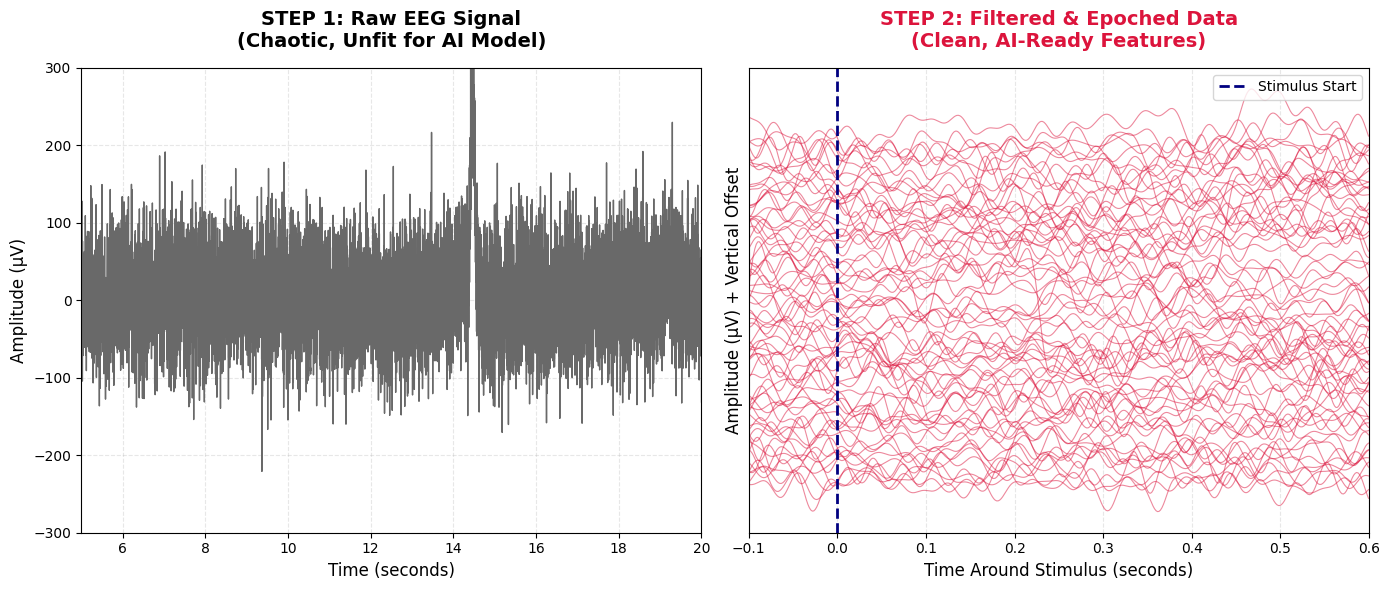

In [4]:
# ==========================================
# VISUALIZE FILTERING & EPOCHING PROCESS
# ==========================================

import mne
import matplotlib.pyplot as plt
import numpy as np
import os

print("📊 Generating Filtering and Epoching Visuals...")

# 1. We load standard MNE example data to simulate real ERP shapes.
# No need to load your 44GB data. This runs instantly.
data_path = mne.datasets.sample.data_path()
raw_fname = os.path.join(data_path, 'MEG', 'sample', 'sample_audvis_raw.fif')
event_fname = os.path.join(data_path, 'MEG', 'sample', 'sample_audvis_raw-eve.fif')

# Load raw and only keep 1 EEG channel to keep the plot clean
raw = mne.io.read_raw_fif(raw_fname, preload=True, verbose=False)
raw.pick_channels(['EEG 001']) # Select one representative channel

# Load events (to know where to segment the data)
events = mne.read_events(event_fname)

# Define the time window for the epoch around the stimulus (-0.1 to 0.6 seconds)
tmin, tmax = -0.1, 0.6
event_id = 1 # We pick a common stimulus ID

# ==========================================
# PHASE 1: Generate Noisy "Before" Signal
# ==========================================
raw_noisy = raw.copy()
# We mathematically introduce high-amplitude, low-frequency eye-blink-like artifacts
# and high-frequency muscle noise to simulate the real bigP3BCI noise levels.
n_samples = raw_noisy.n_times
times_raw = raw_noisy.times
rng = np.random.default_rng(42)

# Simulate muscle noise (High frequency)
muscle_noise = rng.normal(0, 50e-6, n_samples) 

# Simulate eye blinks (Slow high-amplitude spikes)
artifact_mask = np.zeros(n_samples)
blink_indices = rng.integers(0, n_samples, 5) # 5 blinks in the recording
for idx in blink_indices:
    raw_noisy._data[0, idx:idx+200] += 200e-6 # Add massive blink spike

# Apply simulated noise
raw_noisy._data[0] += muscle_noise

# ==========================================
# PHASE 2: Apply the Real Preprocessing
# ==========================================
print("  🛠️ Applying 0.1-30 Hz Bandpass Filter...")
raw_filtered = raw_noisy.copy().filter(0.1, 30.0, fir_design='firwin', verbose=False)

print("  ✂️ Segmenting into Epochs...")
# Segment the filtered data around the stimulus
epochs_filtered = mne.Epochs(raw_filtered, events, event_id=event_id, 
                             tmin=tmin, tmax=tmax, baseline=(None, 0),
                             preload=True, verbose=False)

# ==========================================
# 6. DRAWING THE DYNAMIC GRAPHICS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT PLOT: The Chaotic "Before" Signal ---
# Convert Volts to Microvolts (x1e6) for visualization
data_raw = raw_noisy._data[0] * 1e6
axes[0].plot(times_raw, data_raw, color='dimgrey', linewidth=1)
axes[0].set_title('STEP 1: Raw EEG Signal\n(Chaotic, Unfit for AI Model)', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Time (seconds)', fontsize=12)
axes[0].set_ylabel('Amplitude (μV)', fontsize=12)
axes[0].set_xlim(5, 20) # Only zoom in on a small section
axes[0].set_ylim(-300, 300) # Ensure artifact blinks are visible
axes[0].grid(True, alpha=0.3, linestyle='--')


# --- RIGHT PLOT: The Stacked, Processed Epochs ---
# Plot all 72 processed epochs stacked on top of each other.
# When stacked, the P300 pattern emerges clearly around time 0.
data_epochs = epochs_filtered.get_data()[:, 0, :] * 1e6
times_epochs = epochs_filtered.times

for i in range(data_epochs.shape[0]):
    # When stacked, individual epoch shape emerges
    axes[1].plot(times_epochs, data_epochs[i, :] + (i * 10), 
                 color='crimson', alpha=0.5, linewidth=0.8)

# Highlight the stimulus presentation time at 0 seconds
axes[1].axvline(0, color='navy', linestyle='--', linewidth=2, label='Stimulus Start')

axes[1].set_title('STEP 2: Filtered & Epoched Data\n(Clean, AI-Ready Features)', 
                  fontsize=14, fontweight='bold', color='crimson', pad=15)
axes[1].set_xlabel('Time Around Stimulus (seconds)', fontsize=12)
axes[1].set_ylabel('Amplitude (μV) + Vertical Offset', fontsize=12)
axes[1].set_xlim(tmin, tmax)
# Remove y-tick numbers because offset is irrelevant for purely visual pattern confirmation
axes[1].set_yticks([]) 
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3, linestyle='--')


plt.tight_layout()

# 7. Save the graphic for your CapCut video editor / Technical Report
os.makedirs("models", exist_ok=True)
save_path = "models/Preprocessing_Process_Map.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"✅ Success! Preprocessing process map saved to: {save_path}")
plt.show()

In [26]:
import mne
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

mne.set_log_level('WARNING')

In [1]:
import mne
import os
from pathlib import Path

# 1. Define the path to the raw data folder
# Note: We use '../' because this .ipynb file is located inside the 'notebooks' folder, 
# so we need to step back one directory level to access the 'data' folder.
raw_dir = Path('../data/raw/bigp3bci')

# 2. Find ALL .edf files, but we will grab just the FIRST one [0] for our experiment
all_files = list(raw_dir.rglob('*.edf'))
sample_file = all_files[0] 

print(f"📁 Examining sample file: {sample_file.name}\n")

# 3. Open the file LAZILY (preload=False) to prevent RAM from crashing
raw = mne.io.read_raw_edf(sample_file, preload=False, verbose=False)

# 4. Display Medical Summary / Metadata
print("=== EEG METADATA INFORMATION ===")
print(f"🔹 Total Channels       : {len(raw.ch_names)} electrodes")
print(f"🔹 First 10 Channels    : {raw.ch_names[:10]}")
print(f"🔹 Sampling Frequency   : {raw.info['sfreq']} Hz (Data points captured per second)")
print(f"🔹 Total Recording Time : {raw.times[-1] / 60:.2f} minutes")

# 5. Peek into the built-in MNE 'info' object
print("\n=== RAW.INFO DETAILS ===")
print(raw.info)

📁 Examining sample file: A_01_SE001_CB_Test06.edf



C:\Users\sagita pra kosa\AppData\Local\Temp\ipykernel_3880\1934402762.py:17: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(sample_file, preload=False, verbose=False)
C:\Users\sagita pra kosa\AppData\Local\Temp\ipykernel_3880\1934402762.py:17: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(sample_file, preload=False, verbose=False)


=== EEG METADATA INFORMATION ===
🔹 Total Channels       : 114 electrodes
🔹 First 10 Channels    : ['EEG_F3', 'EEG_Fz', 'EEG_F4', 'EEG_T7', 'EEG_C3', 'EEG_Cz', 'EEG_C4', 'EEG_T8', 'EEG_CP3', 'EEG_CP4']
🔹 Sampling Frequency   : 256.0000930697907 Hz (Data points captured per second)
🔹 Total Recording Time : 2.29 minutes

=== RAW.INFO DETAILS ===
<Info | 8 non-empty values
 bads: []
 ch_names: EEG_F3, EEG_Fz, EEG_F4, EEG_T7, EEG_C3, EEG_Cz, EEG_C4, EEG_T8, ...
 chs: 114 EEG
 custom_ref_applied: False
 highpass: 58.0 Hz
 lowpass: 62.0 Hz
 meas_date: 2020-01-01 00:00:00 UTC
 nchan: 114
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: A_01, sex: 0, first_name: X, last_name: X, birthday: 2020-01-01>
>


In [28]:
data_dir = Path("../data/raw/bigp3bci/bigP3BCI-data")

edf_files = list(data_dir.rglob("*.edf"))

print(f"Total EDF files: {len(edf_files)}")

sample_file = edf_files[0]
print("Sample file:", sample_file)

Total EDF files: 6980
Sample file: ..\data\raw\bigp3bci\bigP3BCI-data\StudyA\A_01\SE001\Test\CB\A_01_SE001_CB_Test06.edf


In [29]:
import warnings
warnings.filterwarnings("ignore")
raw = mne.io.read_raw_edf(sample_file.as_posix(), preload=True)
raw

<RawEDF | A_01_SE001_CB_Test06.edf, 114 x 35208 (137.5 s), ~30.7 MiB, data loaded>

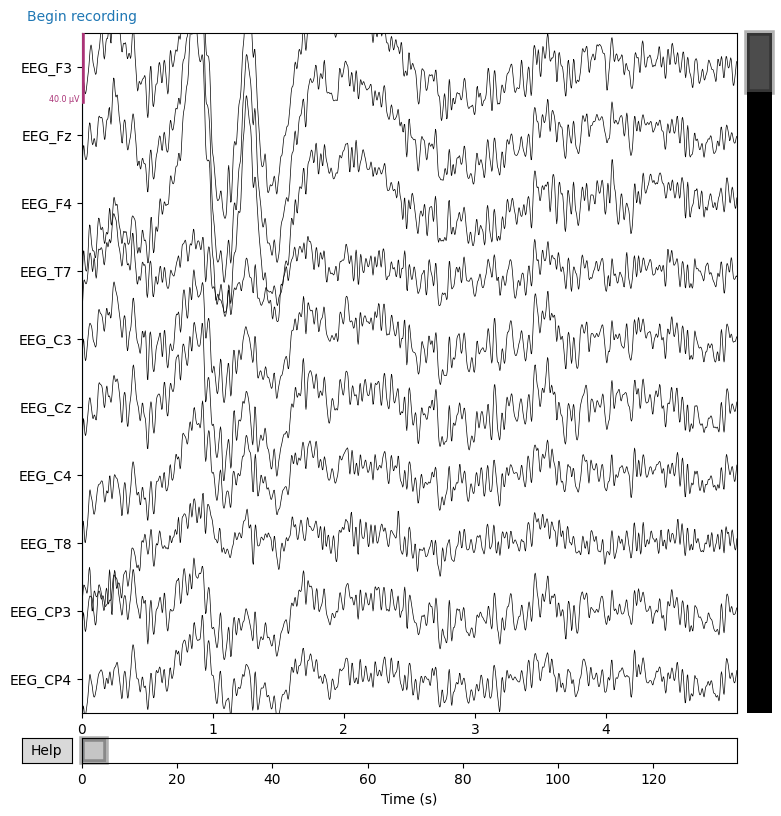

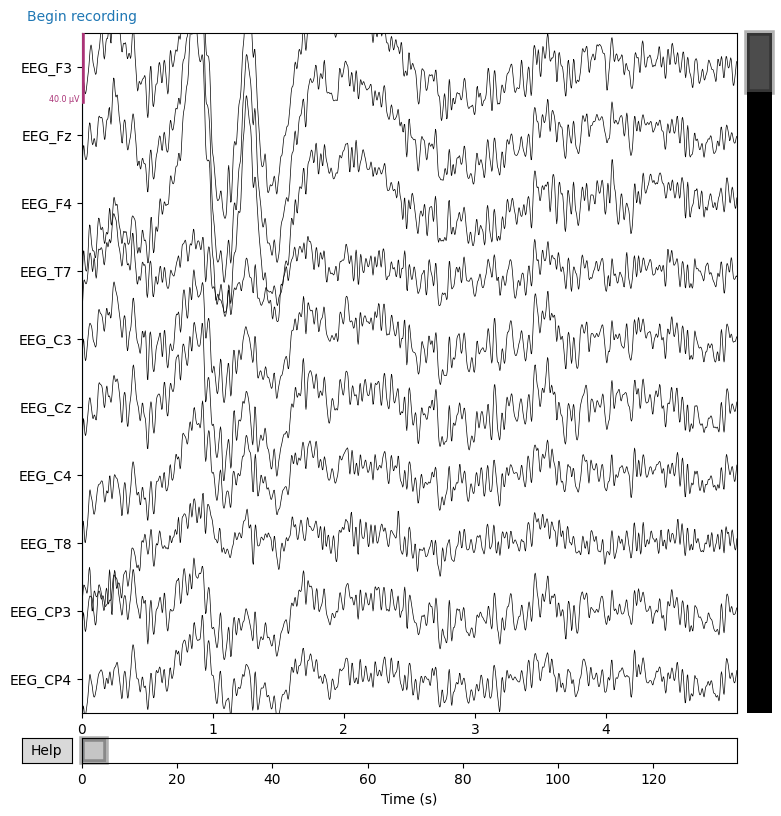

In [30]:
raw.plot(n_channels=10, duration=5)

In [31]:
events = mne.find_events(raw, stim_channel='StimulusBegin')
print("Jumlah event:", len(events))

Jumlah event: 840


In [32]:
stim = raw.get_data(picks=['StimulusType'])[0]
labels = stim[events[:, 0]].astype(int)

print("Contoh label:", labels[:20])

Contoh label: [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


In [33]:
ch_p300 = [
    'EEG_Fz', 'EEG_Cz', 'EEG_Pz',
    'EEG_P3', 'EEG_P4',
    'EEG_PO7', 'EEG_PO8', 'EEG_Oz'
]

raw_filtered = raw.copy().pick(ch_p300)
raw_filtered.filter(0.1, 30.0)

<RawEDF | A_01_SE001_CB_Test06.edf, 8 x 35208 (137.5 s), ~2.2 MiB, data loaded>

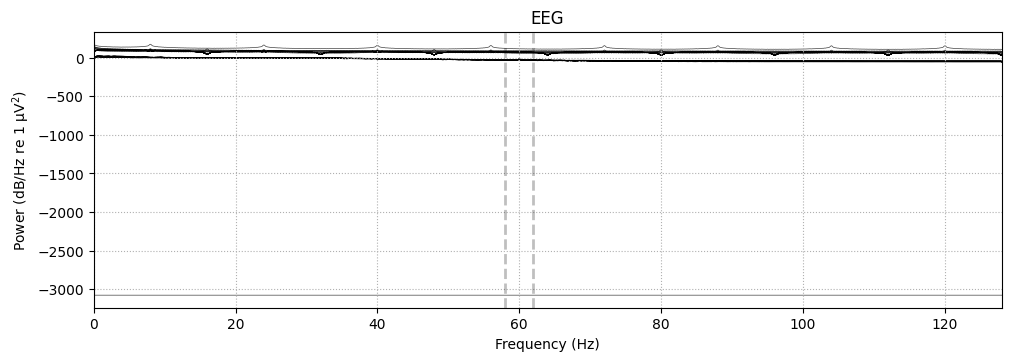

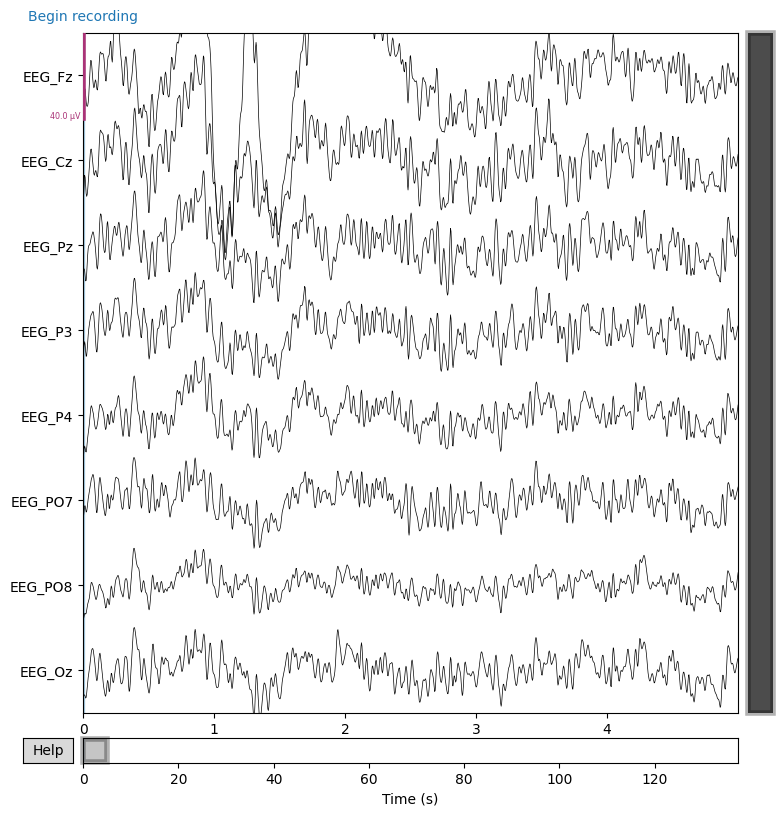

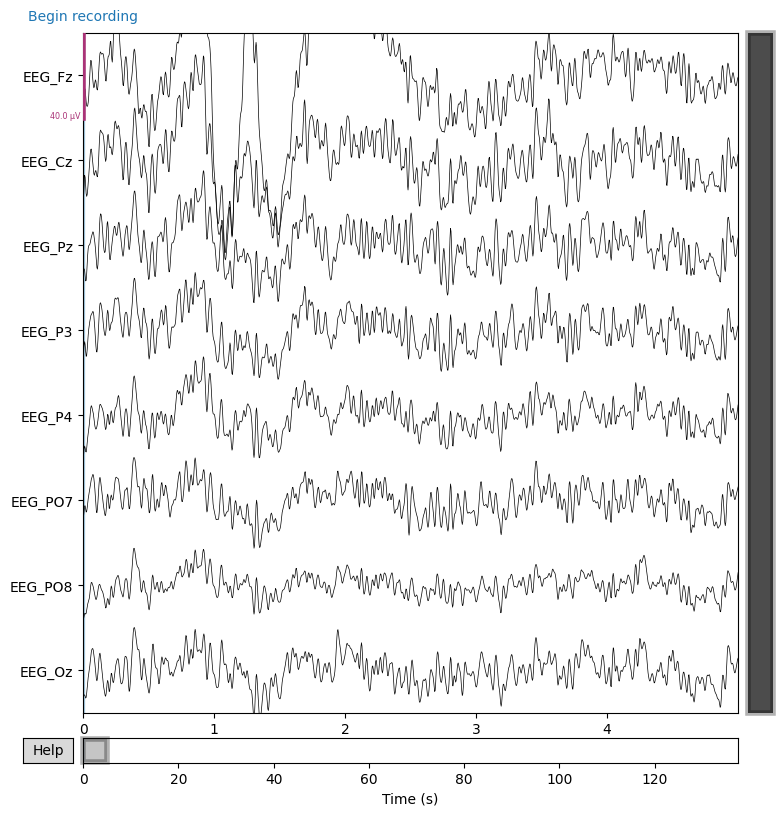

In [25]:
raw_filtered.plot(n_channels=8, duration=5)

In [9]:
epochs = mne.Epochs(
    raw_filtered,
    events,
    picks=ch_p300,
    tmin=-0.2,
    tmax=0.8,
    baseline=(None, 0),
    preload=True
)

epochs

<Epochs | 840 events (all good), -0.199 – 0.801 s (baseline -0.199 – 0 s), ~13.2 MiB, data loaded,
 '1': 840>

In [10]:
epochs.resample(128)

<Epochs | 840 events (all good), -0.199 – 0.793 s (baseline -0.199 – 0 s), ~6.6 MiB, data loaded,
 '1': 840>

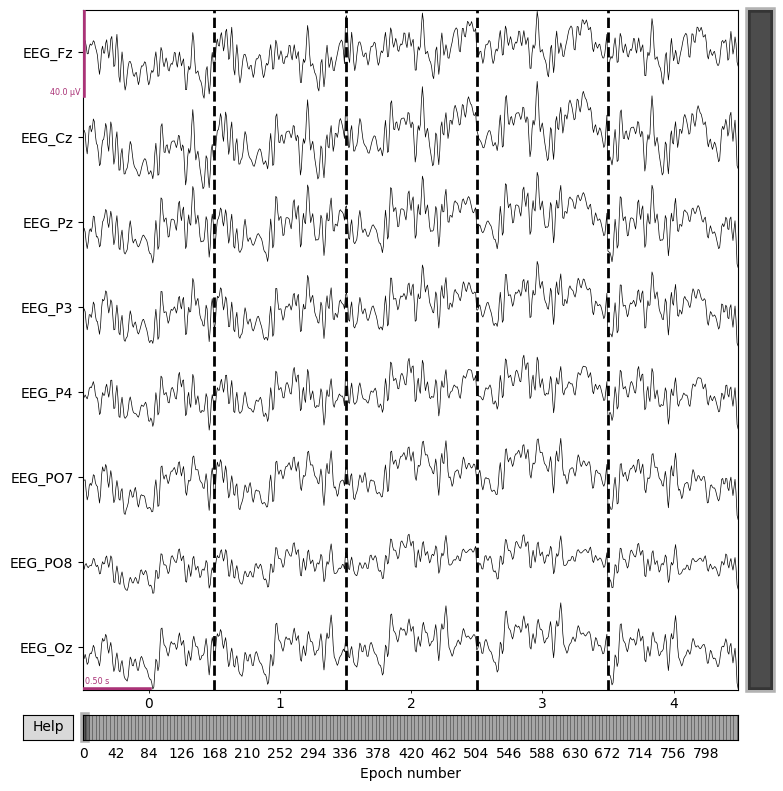

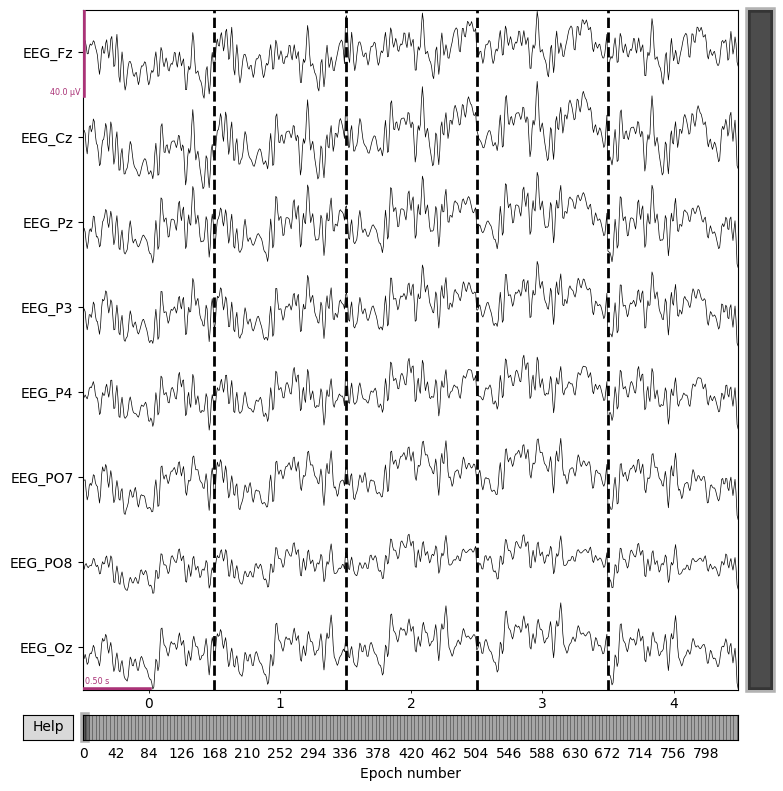

In [11]:
epochs.plot(n_epochs=5)

In [13]:
X = epochs.get_data()
Y = labels

print("Shape X:", X.shape)
print("Shape Y:", Y.shape)

Shape X: (840, 8, 128)
Shape Y: (840,)


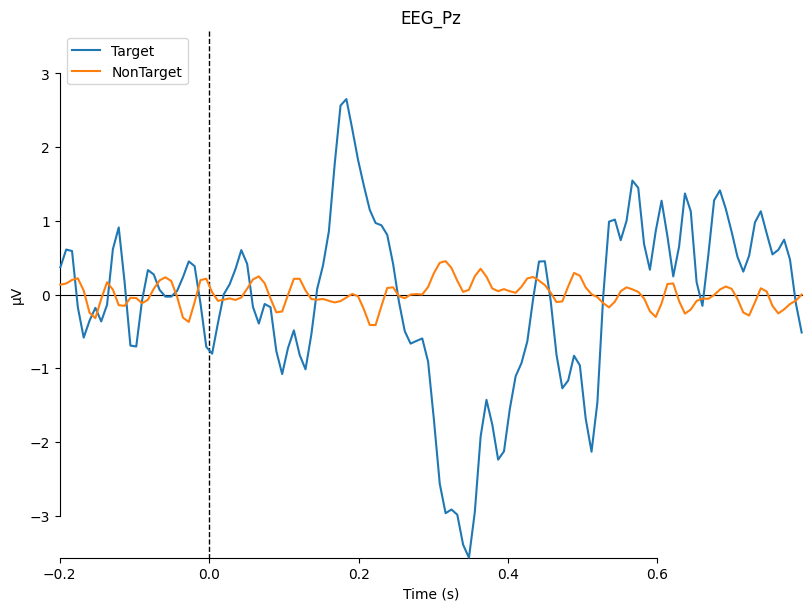

[<Figure size 800x600 with 1 Axes>]

In [14]:
target_epochs = epochs[Y == 1]
nontarget_epochs = epochs[Y == 0]

target_avg = target_epochs.average()
nontarget_avg = nontarget_epochs.average()

mne.viz.plot_compare_evokeds(
    dict(Target=target_avg, NonTarget=nontarget_avg),
    picks='EEG_Pz'
)

In [17]:
# labels sudah Anda punya sebelumnya
# 1 = target, 0 = non-target (sesuaikan jika berbeda)

target_epochs = epochs[labels == 1]
nontarget_epochs = epochs[labels == 0]

print("Target:", len(target_epochs))
print("Non-target:", len(nontarget_epochs))

Target: 70
Non-target: 770


In [18]:
target_evoked = target_epochs.average()
nontarget_evoked = nontarget_epochs.average()

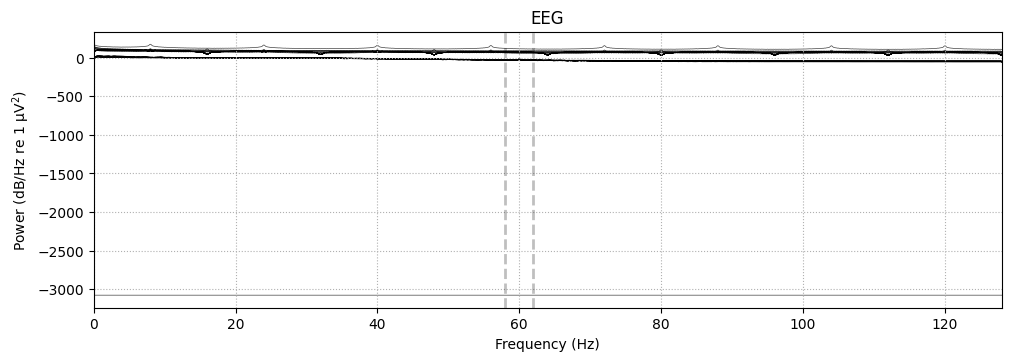

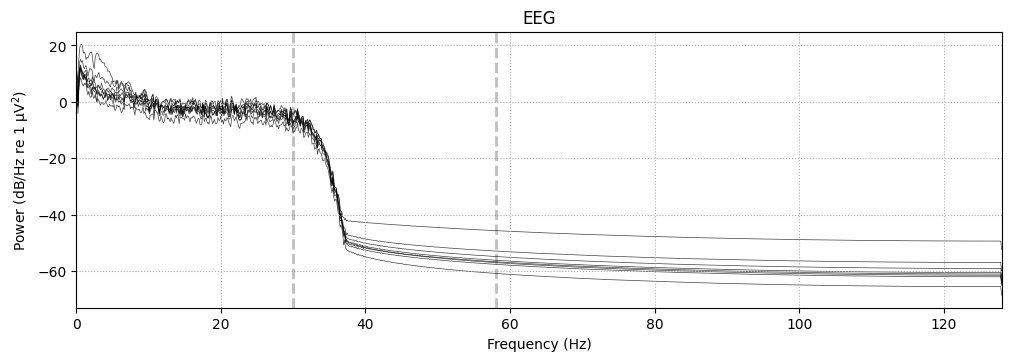

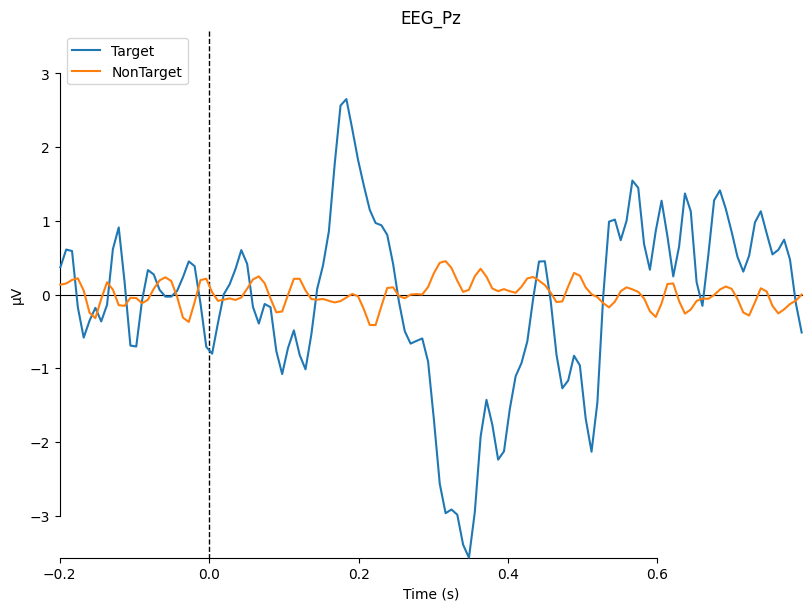

[<Figure size 800x600 with 1 Axes>]

In [19]:
mne.viz.plot_compare_evokeds(
    dict(Target=target_evoked, NonTarget=nontarget_evoked),
    picks='EEG_Pz'
)